# Business Understanding

The goal is to construct models to help find optimal locations for drone hubs for a delivery company, as well as finding relationships between product groups.

# Data Understanding

The data consists of two distinct sets, which do not share a linking component.

The first one contains customer locations on x/y coordinates. This set contains nearly 6000 samples.

The second one contains transaction data of 100 000 transactions. It consists of columns for products (1 - 20) with binary values indicating whether a product was purchased in a transaction or not.

Below listed is the 10 first observations of each dataset.

In [122]:
import pandas as pd

locations = pd.read_csv("../datasets/drone_delivery/drone_cust_locations.csv", sep=";")
prod_groups = pd.read_csv("../datasets/drone_delivery/drone_prod_groups.csv")

locations.head(10)

,clientid,x,y
0,1,622.771572,164.857623
1,2,416.357298,630.193634
2,3,292.735020,567.333231
3,4,737.211288,166.225676
4,5,540.475375,682.912298
5,6,535.469492,318.439661
6,7,640.380050,870.833221
7,8,235.772075,359.048203
8,9,481.896884,661.491838
9,10,730.032789,312.177817


In [123]:
prod_groups.head(10)

,ID,Prod1,Prod2,Prod3,Prod4,Prod5,Prod6,Prod7,Prod8,Prod9,...,Prod11,Prod12,Prod13,Prod14,Prod15,Prod16,Prod17,Prod18,Prod19,Prod20
0,1,0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
1,2,0,1,0,0,0,0,0,0,1,...,0,0,0,0,1,1,1,1,1,1
2,3,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,1
3,4,1,0,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,1,1
4,5,0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,1,1
5,6,0,1,0,0,0,0,1,0,0,...,1,0,0,0,0,0,0,0,0,0
6,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,1
7,8,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
8,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,10,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


We also plot the location data. For visual examination.

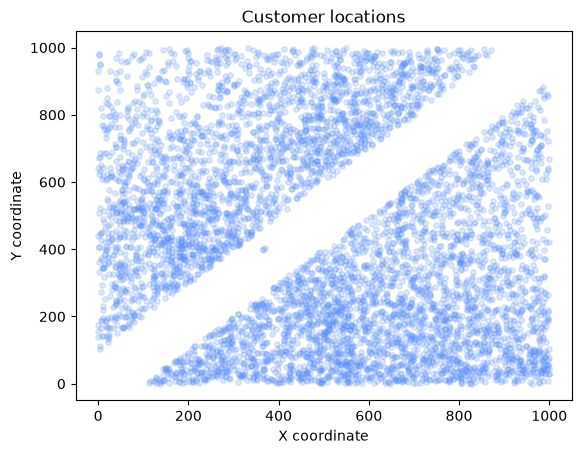

In [124]:
import matplotlib.pyplot as plt

plt.scatter(locations["x"], locations["y"], alpha=0.2, s=15)
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.title("Customer locations")
plt.show()

# Data Preparation

We start by removing unwanted values from the datasets. In the locations data the `clientid`, and in the transaction data the `ID` columns need to be removed.

In [125]:
locations.drop(columns=["clientid"], inplace=True)
locations.columns

Index(['x', 'y'], dtype='str')

In [126]:
prod_groups.drop(columns=["ID"], inplace=True)
prod_groups.columns

Index(['Prod1', ' Prod2', ' Prod3', ' Prod4', ' Prod5', ' Prod6', ' Prod7',
       ' Prod8', ' Prod9', ' Prod10', ' Prod11', ' Prod12', ' Prod13',
       ' Prod14', ' Prod15', ' Prod16', ' Prod17', ' Prod18', ' Prod19',
       ' Prod20'],
      dtype='str')

The data does not contain missing values, so it is now ready for modeling.

However for the association rules mining (Apriori algorithm) we have to convert the product group data values to boolean.

In [127]:
prod_groups = prod_groups.apply(lambda x: x.map(lambda y: True if y == 1 else False))
prod_groups.head(5)

,Prod1,Prod2,Prod3,Prod4,Prod5,Prod6,Prod7,Prod8,Prod9,Prod10,Prod11,Prod12,Prod13,Prod14,Prod15,Prod16,Prod17,Prod18,Prod19,Prod20
0,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True
1,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,True,True,True,True,True
2,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,True
3,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,True
4,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,True


# Modeling

## K-Means clustering

K-Means clustering is used to divide customer locations into groups based on their coordinates (x and y). The cluster centroids are then used as the proposed locations for the drone depots. We assign each location sample a new `depot` value indicating which depot they belong in.

Initially we use 3 clusters, resulting in 3 proposed locations.

In [128]:
from sklearn.cluster import KMeans

k = 3

locations_feats = locations[["x", "y"]]
kmeans = KMeans(init="random", n_clusters=k, random_state=42)
locations["depot"] = kmeans.fit_predict(locations_feats)
centroids = kmeans.cluster_centers_

locations.head(10)

,x,y,depot
0,622.771572,164.857623,0
1,416.357298,630.193634,2
2,292.735020,567.333231,1
3,737.211288,166.225676,0
4,540.475375,682.912298,2
5,535.469492,318.439661,0
6,640.380050,870.833221,2
7,235.772075,359.048203,1
8,481.896884,661.491838,2
9,730.032789,312.177817,0


### Visualizing the clusters

We plot the locations once again, this time highlighting the new clusters and the proposed depot locations marked with "X".

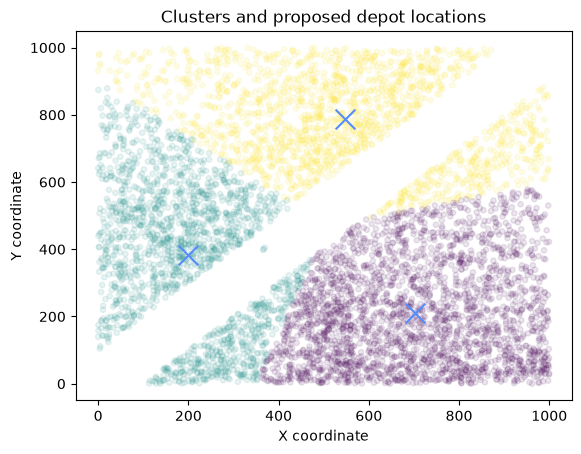

In [129]:
plt.scatter(locations["x"], locations["y"], c=locations["depot"], alpha=0.1, s=15)
plt.scatter(centroids[:, 0], centroids[:, 1], marker="x", s=200)

plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.title("Clusters and proposed depot locations")
plt.show()

### K-Means with different number of depots

The number of depots can have an effect on the resulting locations and computation time, so we test the same algorithm with different amounts of clusters (`k`).

In [130]:
import time

cluster_tests = [3, 7, 10, 15, 25, 50]

for k in cluster_tests:
    start = time.time()
    model = KMeans(init="random", n_clusters=k, random_state=42)
    model.fit(locations_feats)
    end = time.time() - start

    print(f"Depots: {k}, Time: {end}")

Depots: 3, Time: 0.024785757064819336
Depots: 7, Time: 0.037835121154785156
Depots: 10, Time: 0.04116678237915039
Depots: 15, Time: 0.04180645942687988
Depots: 25, Time: 0.05219769477844238
Depots: 50, Time: 0.07887935638427734


We notice that the computation time does change drastically when increasing the number of clusters.

Next we can plot a couple of the tested clusters to see how the depot location changes based on the number of clusters.

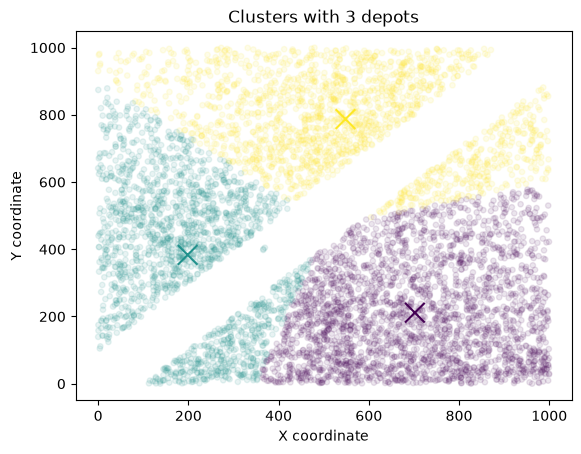

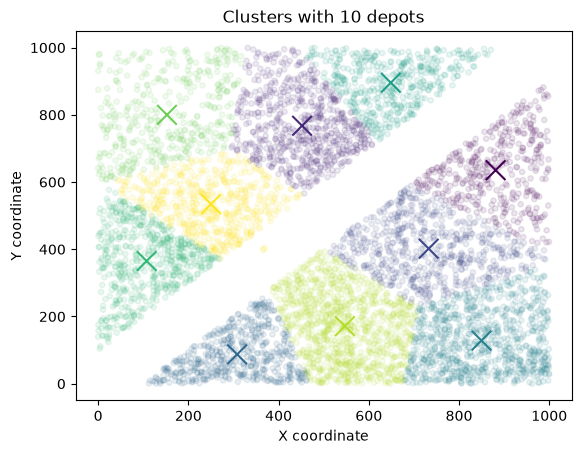

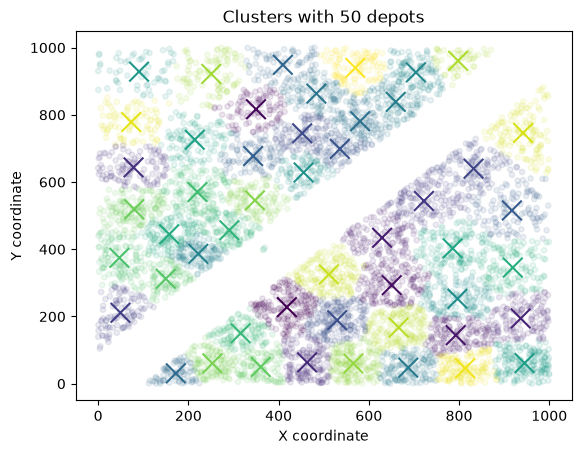

In [131]:
def plot_depots(k):
    model = KMeans(init="random", n_clusters=k, random_state=42)
    model.fit(locations_feats)
    plt.scatter(locations["x"], locations["y"], c=model.labels_, alpha=0.1, s=15)
    plt.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1], marker="x", s=200, c=range(k))

    plt.xlabel("X coordinate")
    plt.ylabel("Y coordinate")
    plt.title(f"Clusters with {k} depots")
    plt.show()

plot_depots(3)
plot_depots(10)
plot_depots(50)

## Agglomerative hierarchical clustering

Alternatively to K-Means we can use agglomerative hierarchical clustering. We again test different number of clusters and compare the resulting customer groups and proposed depot locations with the ones we obtained with K-Means.

In [132]:
from sklearn.cluster import AgglomerativeClustering

k = 3

hierarchical = AgglomerativeClustering(n_clusters=k)
hierarchical_labels = hierarchical.fit_predict(locations_feats)

locations["hierarchical_cluster"] = hierarchical_labels
locations.head(10)

,x,y,depot,hierarchical_cluster
0,622.771572,164.857623,0,0
1,416.357298,630.193634,2,2
2,292.735020,567.333231,1,2
3,737.211288,166.225676,0,0
4,540.475375,682.912298,2,1
5,535.469492,318.439661,0,0
6,640.380050,870.833221,2,1
7,235.772075,359.048203,1,2
8,481.896884,661.491838,2,2
9,730.032789,312.177817,0,0


In [133]:
hierarchical_centroids = locations.groupby("hierarchical_cluster")[["x", "y"]].mean()
print(hierarchical_centroids)

                               x           y
hierarchical_cluster                        
0                     607.735321  151.226451
1                     709.978549  687.401536
2                     218.178835  578.471885


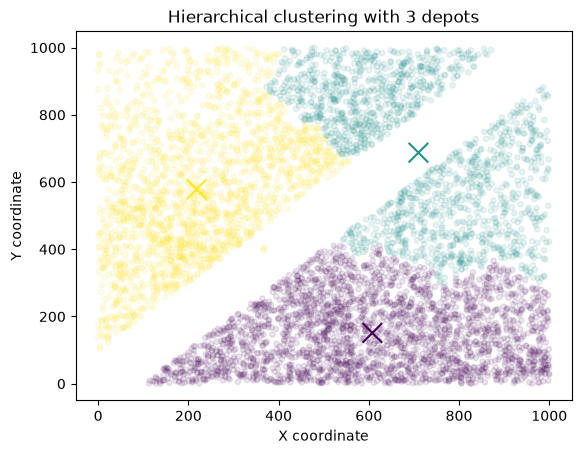

In [134]:
plt.scatter(locations_feats["x"],locations_feats["y"], c=hierarchical_labels, alpha=0.1, s=15)

plt.scatter(hierarchical_centroids["x"], hierarchical_centroids["y"], c=hierarchical_centroids.index, marker="x", s=200)

plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.title("Hierarchical clustering with 3 depots")
plt.show()

We see that for 3 depots the result changed slightly between K-Means and hierarchical clustering.

To see the differences we run hierarchical clustering with similar `k` values like we did with K-Means.

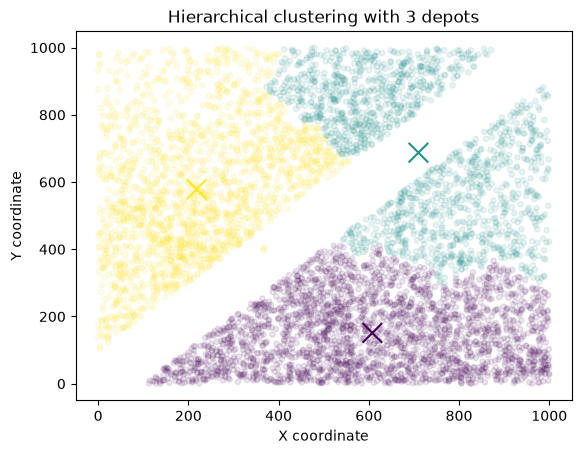

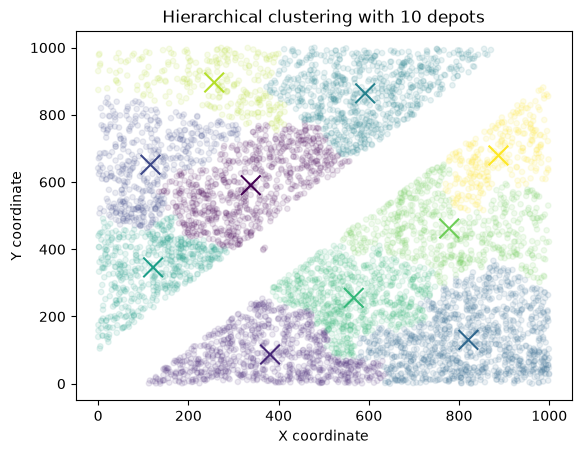

In [135]:
for k in [3, 10]:
    hierarchical = AgglomerativeClustering(n_clusters=k)
    labels = hierarchical.fit_predict(locations_feats)

    centroids = pd.DataFrame({
        "x": locations_feats["x"],
        "y": locations_feats["y"],
        "cluster": labels
    }).groupby("cluster")[["x", "y"]].mean()

    plt.scatter(locations_feats["x"], locations_feats["y"], c=labels, alpha=0.1, s=15)
    plt.scatter(centroids["x"], centroids["y"], c=centroids.index, marker="x", s=200)

    plt.xlabel("X coordinate")
    plt.ylabel("Y coordinate")
    plt.title(f"Hierarchical clustering with {k} depots")
    plt.show()

## Association rule mining



Next we will go through the product group dataset and look for interesting associations between product groups. For this we use the Apriori algorithm.

In [136]:
from mlxtend.frequent_patterns import apriori, association_rules

frequent_itemsets = apriori(prod_groups, min_support=0.01, use_colnames=True)
frequent_itemsets

,support,itemsets
0,0.10998,frozenset({Prod1})
1,0.13098,frozenset({ Prod2})
2,0.03271,frozenset({ Prod3})
3,0.03585,frozenset({ Prod4})
4,0.10459,frozenset({ Prod5})
...,...,...
165,0.02030,"frozenset({ Prod20, Prod19, Prod15})"
166,0.02203,"frozenset({ Prod20, Prod19, Prod16})"
167,0.02052,"frozenset({ Prod20, Prod18, Prod19})"
168,0.01101,"frozenset({ Prod5, Prod12, Prod20, Prod19})"


In [137]:
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)
rules = rules.sort_values(by="confidence", ascending=False)

rules[
    ["antecedents", "consequents", "support", "confidence", "lift"]
].sort_values("lift", ascending=False).head(10)

,antecedents,consequents,support,confidence,lift
74,"frozenset({ Prod20, Prod9})","frozenset({ Prod19, Prod15})",0.01919,0.522035,17.166551
76,"frozenset({ Prod19, Prod15})","frozenset({ Prod20, Prod9})",0.01919,0.631042,17.166551
75,"frozenset({ Prod20, Prod15})","frozenset({ Prod19, Prod9})",0.01919,0.856314,17.139995
69,"frozenset({ Prod5, Prod20})","frozenset({ Prod12, Prod19})",0.01101,0.583157,15.025941
48,"frozenset({ Prod20, Prod9})",frozenset({ Prod15}),0.02119,0.576442,4.852204
43,"frozenset({ Prod9, Prod16})",frozenset({ Prod15}),0.01820,0.575949,4.848059
10,"frozenset({ Prod2, Prod9})",frozenset({ Prod15}),0.01843,0.574143,4.832856
70,"frozenset({ Prod20, Prod19, Prod9})",frozenset({ Prod15}),0.01919,0.573692,4.829058
46,"frozenset({ Prod19, Prod9})",frozenset({ Prod15}),0.02861,0.572658,4.820355
17,"frozenset({ Prod5, Prod9})",frozenset({ Prod15}),0.01409,0.572299,4.817331


# Evaluation

## Comparing clustering methods

K-Means and hierarchical clustering produced similar customer groupings, but the exact cluster borders and proposed depot locations differed slightly. When the number of depots increased, the results depict smaller customer groups.

K-Means provides clear cluster centroids which can be used as depot location proposals. K-Means was also very computationally efficient on this dataset. In hierarchical clustering, the mean coordinates of all outcome clusters were used as approximate depot locations.

The choice of number of depots heavily depends on the company's requirements. Larger number of depots can result in faster delivery times to customers but also increases the number of facilities that have to be operated/maintained.

## Association rules

The association rules show a number of strong relationships between product groups (products bought together in one transaction). Strongest ones have lift values of over 17 which indicates that those products are bought together more often than would be expected if the products were alone.

For example the rule `{Prod20, Prod15} -> {Prod19, Prod9}` has a confidence of ~86% and a lift of ~17.14, meaning that many of the transactions containing Prod20 and Prod15 also contain Prod19 and Prod9.

We can see that the support value for the individual rules is quite low (1-3%) which could indicate that the relationships affect specific subsets of transactions rather than the majority of the customers.

These metrics can be helpful for the company when considering product recommendations or "combination discounts".

# Deployment

## Depot locations

The clustering results can be used as help when deciding the placement of the drone hubs. The amount of depots can be adjusted to the company's operational needs and other boundaries.

## Association rules

The discovered association rules could be used in improving product recommendations and combinations. The recommendations should primarily consider support, lift and confidence. High lift values indicate strong association, support indicates how common a combination is and confidence indicates how often recommended products appear when the antecedent is present.